# Gráficos de Pastel (Pie Charts) en Matplotlib

**Curso:** Python para Ciencia de Datos \
**Fecha:** Octubre 2025 \
**Ruta:** Fundamentos de Data Science e IA \
**Repositorio:** `bootcamp-fundamentos-ciencia-de-datos`

## 📋 Índice

1. [¿Qué son los Gráficos de Pastel?](#concepto)
2. [Sintaxis Básica](#sintaxis)
3. [Formato de Porcentajes con autopct](#autopct)
4. [Personalización Avanzada](#personalizacion)
5. [Casos de Uso en Data Science](#casos-uso)
6. [Matplotlib vs Seaborn](#matplotlib-seaborn)
7. [Recursos Adicionales](#recursos)

## ¿Qué son los Gráficos de Pastel?

Los **gráficos de pastel** (pie charts) representan proporciones de un total como sectores de un círculo.

### ¿Cuándo usar gráficos de pastel?

✅ **Ideal para:**
- Mostrar partes de un todo (proporciones)
- Comparar categorías (máximo 5-7 categorías)
- Presentaciones ejecutivas simples
- Datos que suman 100%

❌ **No usar para:**
- Muchas categorías (>7)
- Comparaciones precisas de valores
- Tendencias temporales
- Valores negativos

### Anatomía de un gráfico de pastel
```
       Título
          ↓
    ┌─────────────┐
    │   15%   30% │ ← Porcentajes
    │     ╱─╲     │
    │    │   │    │
    │     ╲─╱     │
    │   25%   30% │
    └─────────────┘
         ↑
      Leyenda
```

### Alternativas modernas

Los gráficos de pastel son útiles, pero considera:
- 📊 **Gráfico de barras**: Mejor para comparaciones precisas
- 📈 **Gráfico de dona**: Variante moderna del pastel
- 🎯 **Treemap**: Para jerarquías de datos

In [17]:
import matplotlib.pyplot as plt
import numpy as np

print("✅ Bibliotecas importadas")

✅ Bibliotecas importadas


---

## Sintaxis Básica

### Función plt.pie()
```python
plt.pie(sizes,              # Tamaños de cada sector
        labels=names,       # Etiquetas
        autopct='%1.1f%%',  # Formato de porcentajes
        colors=colors,      # Colores personalizados
        explode=explode,    # "Explotar" sectores
        shadow=True)        # Sombra
```

### Gráfico básico

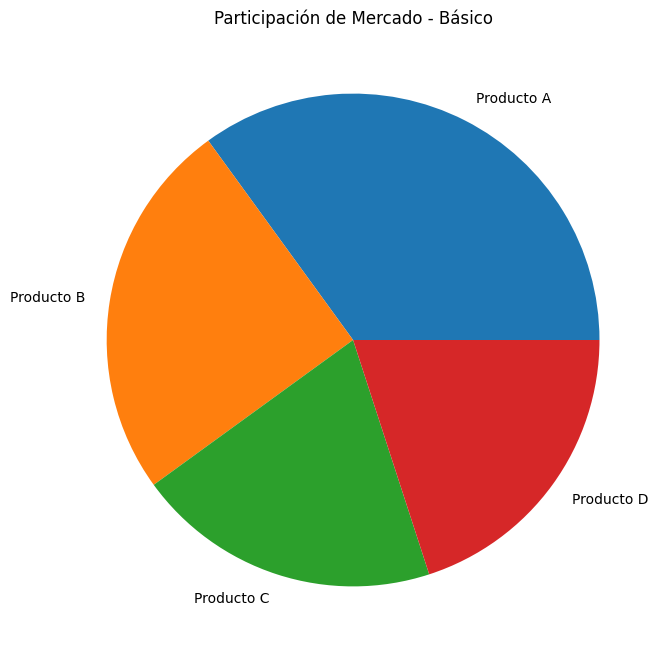

In [18]:
# Datos de ejemplo: Participación de mercado de productos
productos = ['Producto A', 'Producto B', 'Producto C', 'Producto D']
participacion = [35, 25, 20, 20]

# Gráfico de pastel básico
plt.figure(figsize=(8, 8))
plt.pie(participacion, labels=productos)
plt.title('Participación de Mercado - Básico')
plt.show()

---

## Formato de Porcentajes con autopct

El parámetro `autopct` controla cómo se muestran los porcentajes en cada sector.

### Cadenas de formato disponibles

| Formato | Resultado | Ejemplo |
|---------|-----------|---------|
| `'%1.1f%%'` | 1 decimal con símbolo % | `35.7%` |
| `'%1.0f%%'` | Sin decimales con símbolo % | `36%` |
| `'%1.2f%%'` | 2 decimales con símbolo % | `35.68%` |
| `'%1.1f'` | 1 decimal sin símbolo | `35.7` |
| `'%1.1f unidades'` | Texto personalizado | `35.7 unidades` |

### Explicación del formato
```
'%1.1f%%'
  │ │││└─ Segundo % es literal (se muestra)
  │ │││
  │ ││└─ Tipo: f (float/decimal)
  │ │└── Decimales: .1 (un decimal)
  │ └─── Ancho mínimo: 1 dígito
  └───── Marcador de formato
```

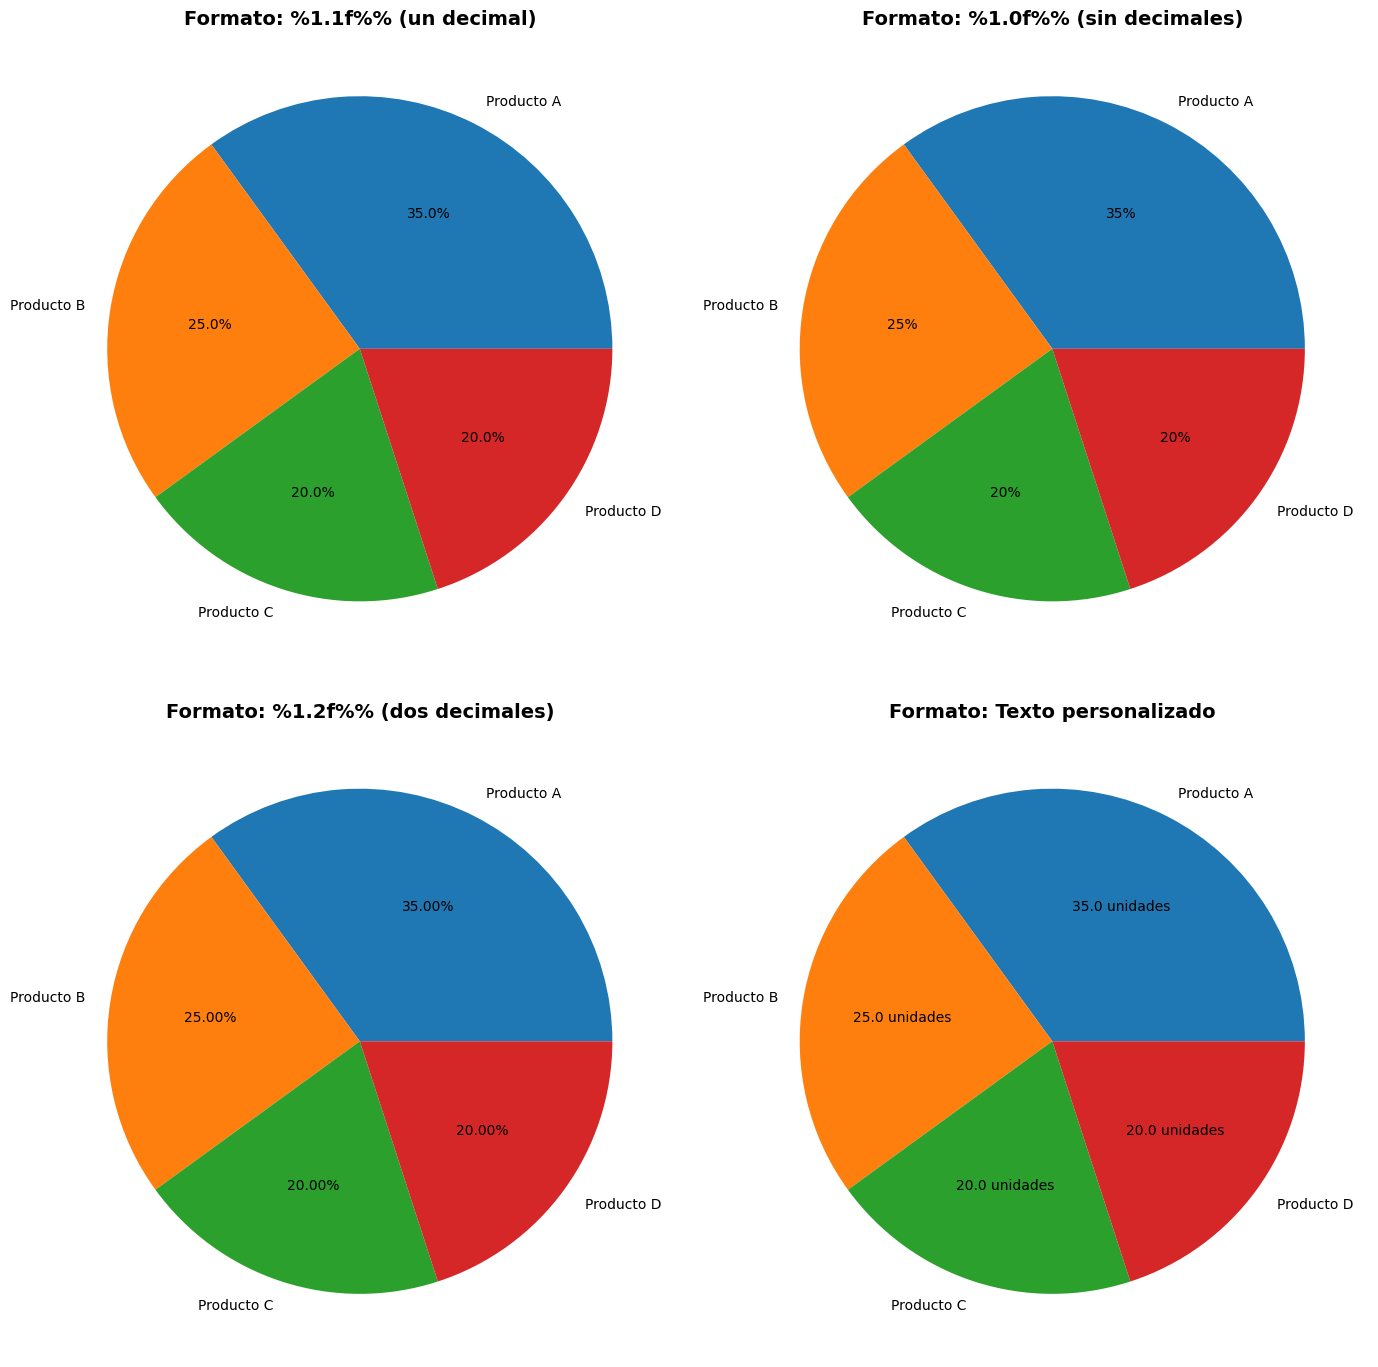

In [19]:
# Ejemplos de diferentes formatos
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# 1. Un decimal con %
axes[0, 0].pie(participacion, labels=productos, autopct='%1.1f%%')
axes[0, 0].set_title('Formato: %1.1f%% (un decimal)', fontsize=14, fontweight='bold')

# 2. Sin decimales
axes[0, 1].pie(participacion, labels=productos, autopct='%1.0f%%')
axes[0, 1].set_title('Formato: %1.0f%% (sin decimales)', fontsize=14, fontweight='bold')

# 3. Dos decimales
axes[1, 0].pie(participacion, labels=productos, autopct='%1.2f%%')
axes[1, 0].set_title('Formato: %1.2f%% (dos decimales)', fontsize=14, fontweight='bold')

# 4. Texto personalizado
axes[1, 1].pie(participacion, labels=productos, autopct='%1.1f unidades')
axes[1, 1].set_title('Formato: Texto personalizado', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Funciones personalizadas en autopct

Para control total, puedes usar una función que calcule valores personalizados.

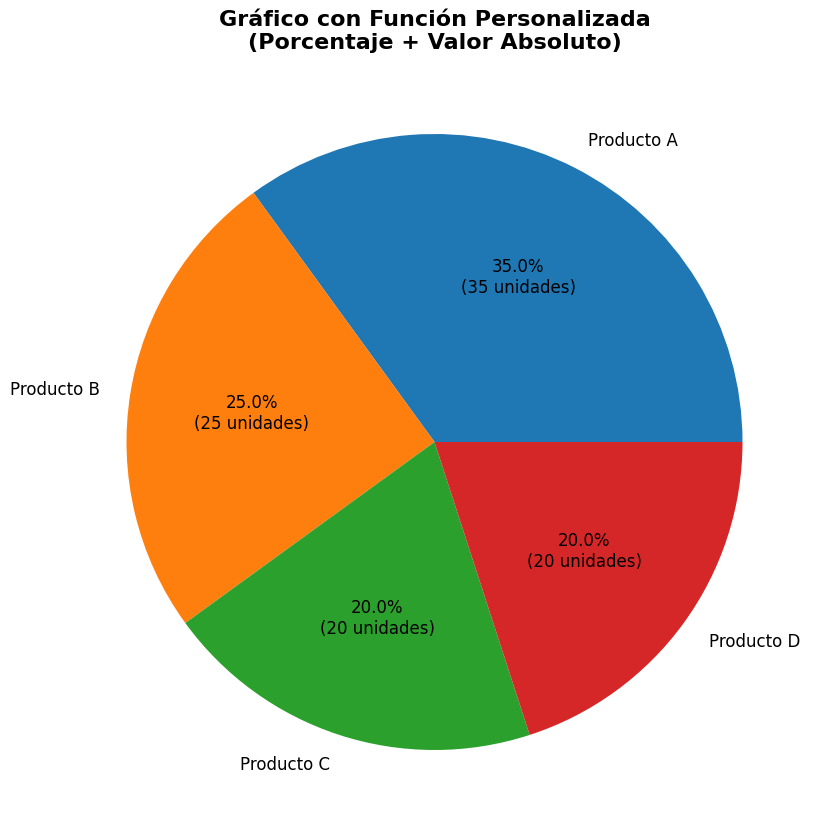

In [20]:
# Función personalizada para mostrar porcentaje y valor absoluto
def formato_personalizado(pct):
    """
    Muestra porcentaje y valor absoluto.

    Args:
        pct: Porcentaje calculado por matplotlib

    Returns:
        str: Texto formateado
    """
    total = sum(participacion)
    valor_absoluto = int(round(pct/100. * total))
    return f'{pct:.1f}%\n({valor_absoluto} unidades)'

plt.figure(figsize=(10, 10))
plt.pie(participacion,
        labels=productos,
        autopct=formato_personalizado,
        textprops={'fontsize': 12})
plt.title('Gráfico con Función Personalizada\n(Porcentaje + Valor Absoluto)',
          fontsize=16, fontweight='bold')
plt.show()

---

## Personalización Avanzada

### Colores personalizados

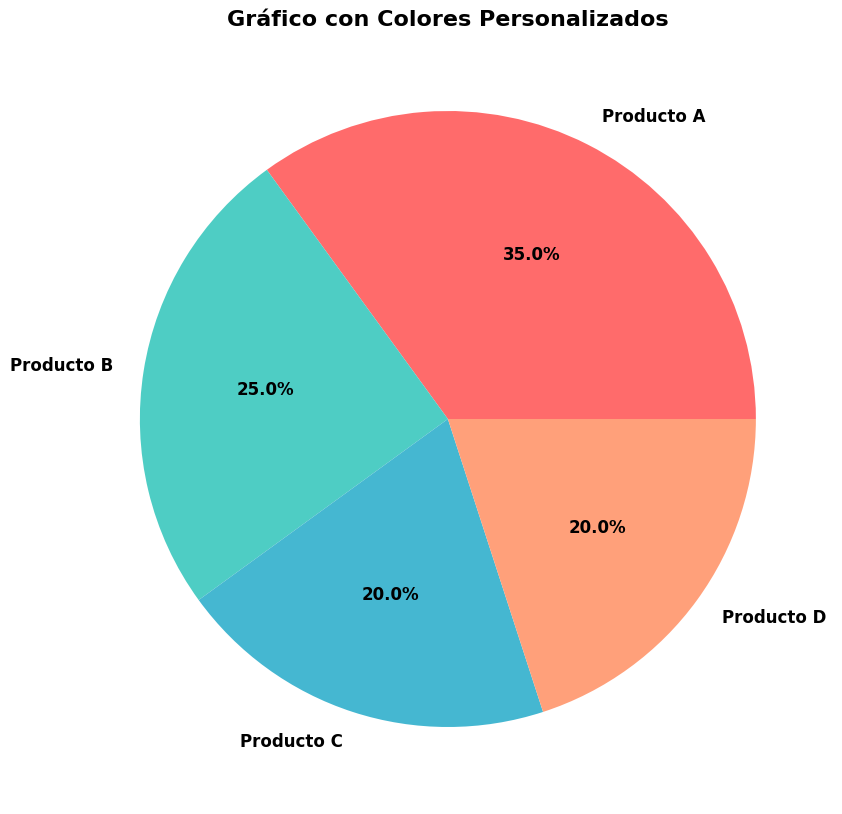

In [21]:
# Paleta de colores personalizada
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

plt.figure(figsize=(10, 10))
plt.pie(participacion,
        labels=productos,
        autopct='%1.1f%%',
        colors=colores,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Gráfico con Colores Personalizados', fontsize=16, fontweight='bold')
plt.show()

### Explotar sectores (destacar)

El parámetro `explode` separa sectores del centro para destacarlos.

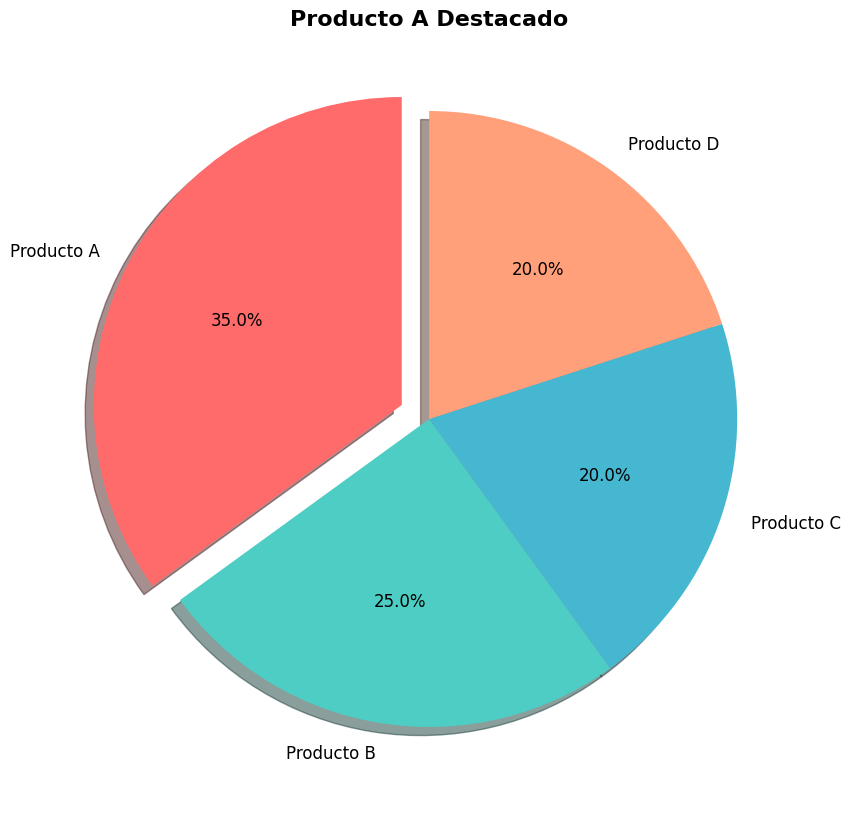

In [22]:
# Explotar el primer sector (índice 0)
explotar = (0.1, 0, 0, 0)  # 0.1 = 10% de separación

plt.figure(figsize=(10, 10))
plt.pie(participacion,
        labels=productos,
        autopct='%1.1f%%',
        colors=colores,
        explode=explotar,
        shadow=True,  # Agregar sombra
        startangle=90,  # Rotar 90 grados
        textprops={'fontsize': 12})
plt.title('Producto A Destacado', fontsize=16, fontweight='bold')
plt.show()

### Gráfico completo con todas las personalizaciones

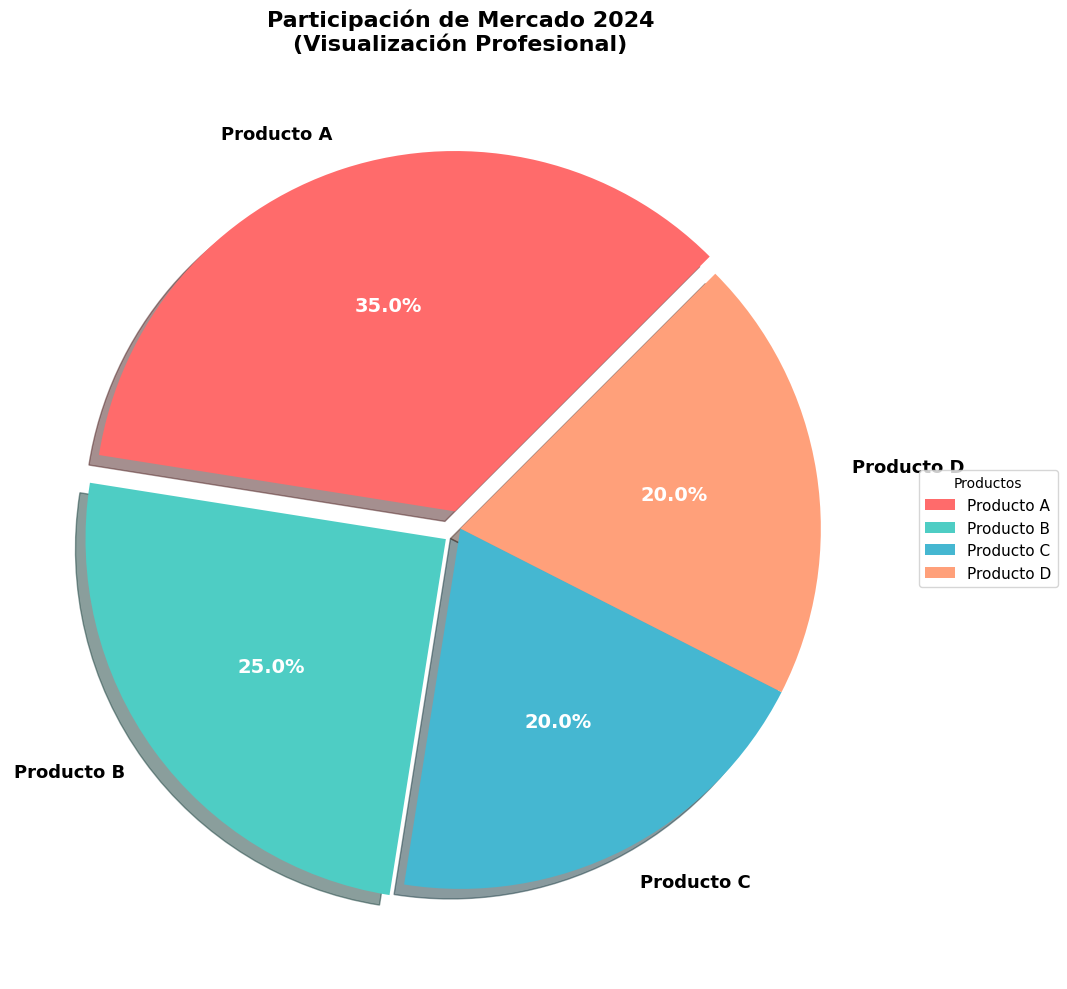

In [23]:
# Gráfico profesional completo
fig, ax = plt.subplots(figsize=(12, 10))

# Explotar sectores más importantes
explotar = (0.05, 0.05, 0, 0)

# Gráfico
wedges, texts, autotexts = ax.pie(
    participacion,
    labels=productos,
    autopct='%1.1f%%',
    colors=colores,
    explode=explotar,
    shadow=True,
    startangle=45,
    textprops={'fontsize': 12}
)

# Personalizar textos de porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

# Personalizar etiquetas
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')

# Leyenda
ax.legend(wedges, productos,
          title="Productos",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=11)

plt.title('Participación de Mercado 2024\n(Visualización Profesional)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---

## Casos de Uso en Data Science

### Caso de Uso 1: Análisis de Canales de Venta

**Contexto:** El director comercial necesita ver qué porcentaje de ventas proviene de cada canal (online, tiendas físicas, distribuidores, telefónico) para reasignar recursos.

**Objetivo:** Visualizar claramente la distribución de ventas por canal.

In [24]:
# Datos de ventas por canal (en miles de dólares)
canales = ['Online', 'Tiendas Físicas', 'Distribuidores', 'Telefónico']
ventas_canal = [450, 380, 120, 50]

# Calcular métricas
total_ventas = sum(ventas_canal)
print(f"📊 Análisis de Canales de Venta")
print(f"💰 Ventas totales: ${total_ventas}K")
print(f"\n📈 Desglose por canal:")
for canal, venta in zip(canales, ventas_canal):
    porcentaje = (venta/total_ventas)*100
    print(f"  - {canal}: ${venta}K ({porcentaje:.1f}%)")

📊 Análisis de Canales de Venta
💰 Ventas totales: $1000K

📈 Desglose por canal:
  - Online: $450K (45.0%)
  - Tiendas Físicas: $380K (38.0%)
  - Distribuidores: $120K (12.0%)
  - Telefónico: $50K (5.0%)


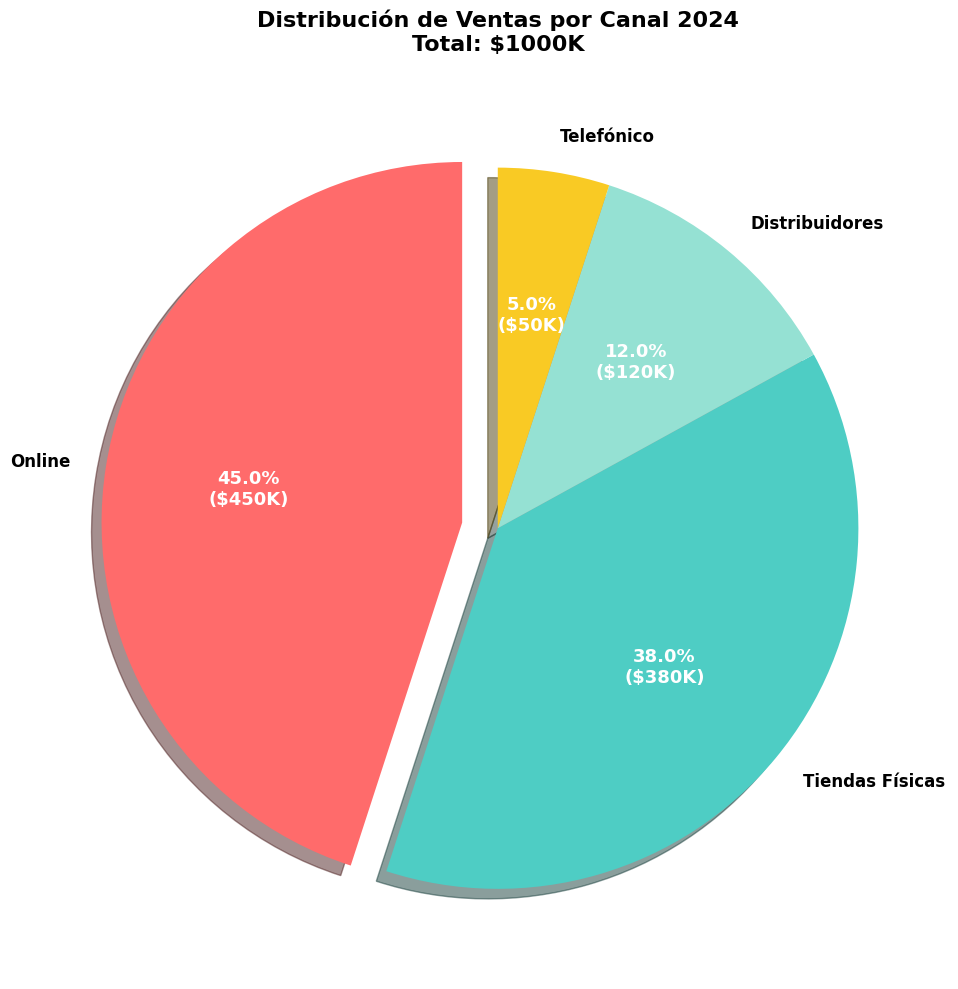

In [25]:
# Función para mostrar porcentaje y valor
def formato_ventas(pct):
    total = sum(ventas_canal)
    valor = int(round(pct/100. * total))
    return f'{pct:.1f}%\n(${valor}K)'

# Colores para cada canal
colores_canales = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F9CA24']

# Destacar canal principal
explotar = (0.1, 0, 0, 0)

fig, ax = plt.subplots(figsize=(12, 10))

wedges, texts, autotexts = ax.pie(
    ventas_canal,
    labels=canales,
    autopct=formato_ventas,
    colors=colores_canales,
    explode=explotar,
    shadow=True,
    startangle=90
)

# Estilo de textos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title(f'Distribución de Ventas por Canal 2024\nTotal: ${total_ventas}K',
            fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**🎯 Insights del Caso 1:**

✅ **Online domina**: 45% de las ventas (canal principal)
✅ **Tiendas físicas**: 38% (segundo lugar)
✅ **Distribuidores**: 12% (potencial de crecimiento)
✅ **Telefónico**: 5% (considerar descontinuar)

**Decisiones de negocio:**
- 💻 Invertir más en plataforma online (+20% presupuesto)
- 🏢 Optimizar tiendas físicas (cerrar las menos rentables)
- 📦 Expandir red de distribuidores (bajo costo, alto margen)
- ☎️ Migrar telefónico a chatbot (reducir costos)

**ROI esperado:**
- Reasignación de recursos del canal telefónico al online puede incrementar ventas en 15-20%

### Caso de Uso 2: Segmentación de Clientes por Valor (RFM)

**Contexto:** Después del análisis RFM, tienes clientes segmentados en VIP, Leales, Regulares y En Riesgo. Necesitas mostrar la distribución para priorizar estrategias de retención.

**Objetivo:** Visualizar proporción de cada segmento y su contribución a ingresos.

In [26]:
# Datos de segmentación de clientes
segmentos = ['VIP', 'Leales', 'Regulares', 'En Riesgo']
num_clientes = [120, 380, 850, 450]
ingresos_segmento = [450, 520, 380, 150]  # En miles

# Análisis
total_clientes = sum(num_clientes)
total_ingresos = sum(ingresos_segmento)

print("👥 Análisis de Segmentación de Clientes")
print(f"📊 Total de clientes: {total_clientes:,}")
print(f"💰 Ingresos totales: ${total_ingresos}K")
print(f"\n📈 Desglose por segmento:")
for seg, clientes, ingresos in zip(segmentos, num_clientes, ingresos_segmento):
    pct_clientes = (clientes/total_clientes)*100
    pct_ingresos = (ingresos/total_ingresos)*100
    ingreso_promedio = ingresos/clientes
    print(f"\n  {seg}:")
    print(f"    Clientes: {clientes:,} ({pct_clientes:.1f}%)")
    print(f"    Ingresos: ${ingresos}K ({pct_ingresos:.1f}%)")
    print(f"    Ingreso promedio: ${ingreso_promedio:.2f}K por cliente")

👥 Análisis de Segmentación de Clientes
📊 Total de clientes: 1,800
💰 Ingresos totales: $1500K

📈 Desglose por segmento:

  VIP:
    Clientes: 120 (6.7%)
    Ingresos: $450K (30.0%)
    Ingreso promedio: $3.75K por cliente

  Leales:
    Clientes: 380 (21.1%)
    Ingresos: $520K (34.7%)
    Ingreso promedio: $1.37K por cliente

  Regulares:
    Clientes: 850 (47.2%)
    Ingresos: $380K (25.3%)
    Ingreso promedio: $0.45K por cliente

  En Riesgo:
    Clientes: 450 (25.0%)
    Ingresos: $150K (10.0%)
    Ingreso promedio: $0.33K por cliente


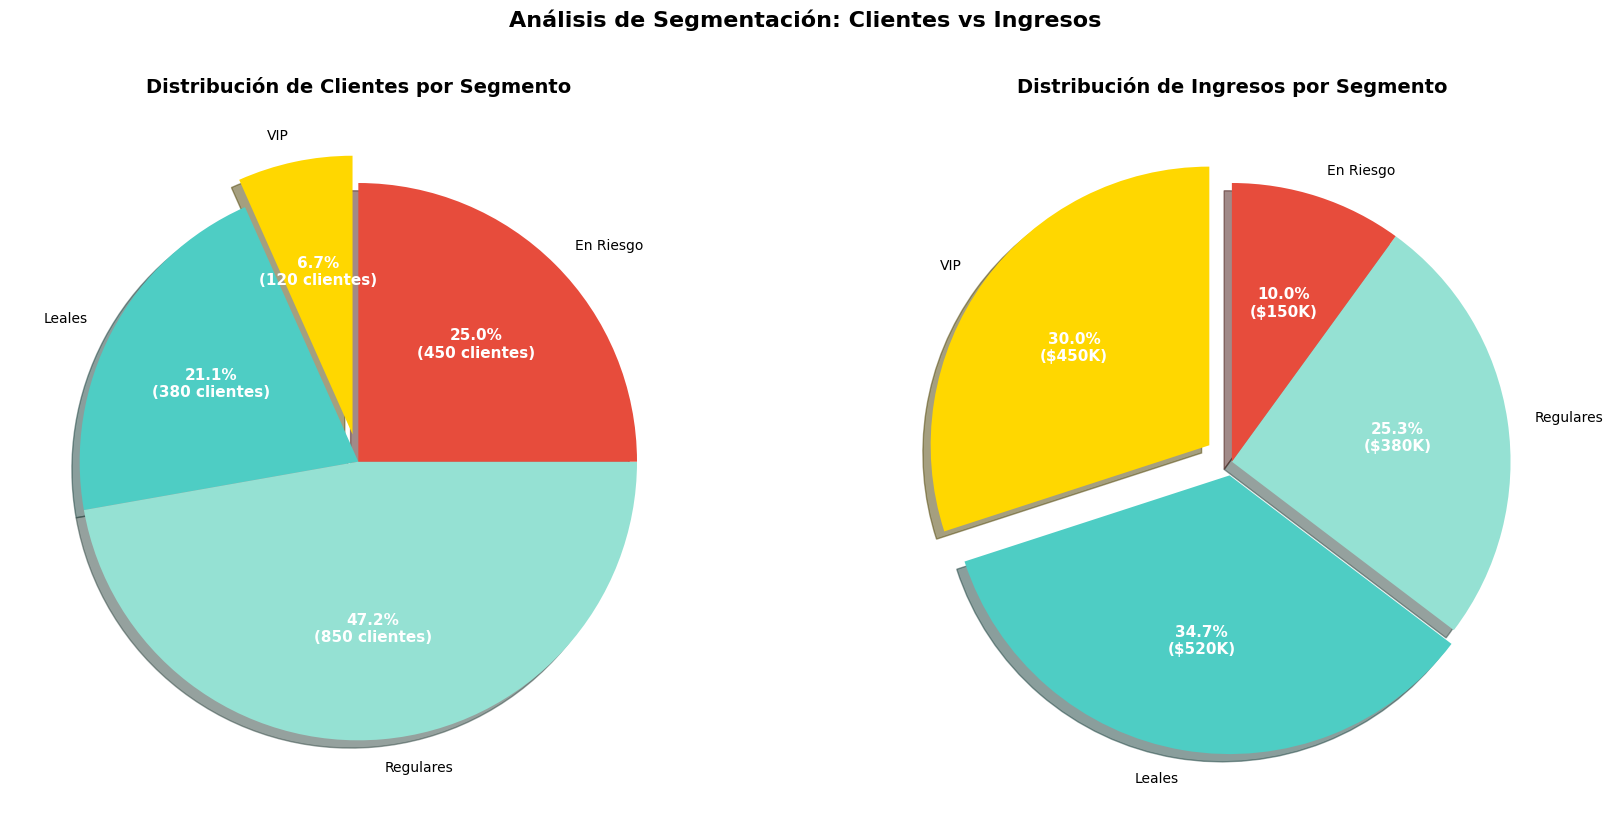

In [27]:
# Crear dos gráficos de pastel lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Colores según importancia del segmento
colores_segmentos = ['#FFD700', '#4ECDC4', '#95E1D3', '#E74C3C']

# Gráfico 1: Distribución de clientes
def formato_clientes(pct):
    total = sum(num_clientes)
    valor = int(round(pct/100. * total))
    return f'{pct:.1f}%\n({valor:,} clientes)'

wedges1, texts1, autotexts1 = ax1.pie(
    num_clientes,
    labels=segmentos,
    autopct=formato_clientes,
    colors=colores_segmentos,
    explode=(0.1, 0, 0, 0),
    shadow=True,
    startangle=90
)

for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax1.set_title('Distribución de Clientes por Segmento',
             fontsize=14, fontweight='bold', pad=15)

# Gráfico 2: Distribución de ingresos
def formato_ingresos(pct):
    total = sum(ingresos_segmento)
    valor = int(round(pct/100. * total))
    return f'{pct:.1f}%\n(${valor}K)'

wedges2, texts2, autotexts2 = ax2.pie(
    ingresos_segmento,
    labels=segmentos,
    autopct=formato_ingresos,
    colors=colores_segmentos,
    explode=(0.1, 0.05, 0, 0),
    shadow=True,
    startangle=90
)

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax2.set_title('Distribución de Ingresos por Segmento',
             fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Análisis de Segmentación: Clientes vs Ingresos',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**🎯 Insights del Caso 2:**

✅ **Paradoja del valor**: VIP son 7% de clientes pero 30% de ingresos
✅ **Leales eficientes**: 21% clientes, 34% ingresos (mejor ratio)
✅ **Regulares**: Mayoría (47%) pero solo 25% ingresos
✅ **En Riesgo**: 25% clientes, 10% ingresos (recuperar urgente)

**Estrategias por segmento:**
- 💎 **VIP**: Programa de fidelidad premium, gerente de cuenta dedicado
- 💙 **Leales**: Cross-selling, beneficios exclusivos
- 👤 **Regulares**: Campañas de activación, descuentos por volumen
- ⚠️ **En Riesgo**: Encuestas CSAT, ofertas de retención, contacto directo

**Impacto esperado:**
- Retener 80% de "En Riesgo" = +$120K anuales
- Ascender 10% de "Regulares" a "Leales" = +$50K anuales

**Aplicación a CSAT:**
Correlacionar estos segmentos con satisfacción. ¿Los VIP tienen CSAT más alto? ¿Los "En Riesgo" reportan baja satisfacción?

---

## Matplotlib vs Seaborn: ¿Cuál usar?

### 🎨 Diferencias fundamentales

| Aspecto | Matplotlib | Seaborn |
|---------|-----------|---------|
| **Nivel** | Bajo nivel | Alto nivel |
| **Control** | Total (más código) | Menos (más automático) |
| **Estética** | Básica (requiere personalización) | Moderna (por defecto) |
| **Curva de aprendizaje** | Más pronunciada | Más suave |
| **Flexibilidad** | Máxima | Media-Alta |
| **Integración Pandas** | Manual | Nativa |
| **Gráficos estadísticos** | Manual | Incorporados |

### 🔧 Matplotlib - El "motor" de visualización
```python
# Matplotlib: Control total, más código
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', linewidth=2)
plt.title('Mi Gráfico')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()
```

**Ventajas:**
- ✅ Control absoluto sobre cada elemento
- ✅ Base para otras bibliotecas (Seaborn usa Matplotlib)
- ✅ Gráficos personalizados complejos
- ✅ Documentación extensa

**Desventajas:**
- ❌ Requiere más código para gráficos bonitos
- ❌ Estética básica por defecto
- ❌ No integrado nativamente con Pandas

### 🎨 Seaborn - La capa estética
```python
# Seaborn: Menos código, más bonito
import seaborn as sns

sns.set_style('whitegrid')
sns.lineplot(data=df, x='x', y='y')
plt.show()  # Seaborn usa Matplotlib por debajo
```

**Ventajas:**
- ✅ Gráficos hermosos por defecto
- ✅ Integración perfecta con Pandas
- ✅ Gráficos estadísticos incorporados (boxplot, violin, heatmap)
- ✅ Menos código para resultados complejos

**Desventajas:**
- ❌ Menos control fino
- ❌ Depende de Matplotlib (no es independiente)
- ❌ Limitado a ciertos tipos de gráficos

### 📊 ¿Cuándo usar cada una?

| Situación | Usa | Razón |
|-----------|-----|-------|
| **Aprender fundamentos** | Matplotlib | Base de todo |
| **Gráficos rápidos exploratorios** | Seaborn | Menos código |
| **Presentaciones ejecutivas** | Seaborn | Más bonito |
| **Control total del diseño** | Matplotlib | Personalización |
| **Gráficos estadísticos** | Seaborn | Ya incorporados |
| **Publicaciones científicas** | Matplotlib | Estándares específicos |
| **Dashboards interactivos** | Plotly/Dash | Interactividad |

### 🎯 Recomendación para tu ruta

**En orden de aprendizaje:**

1. **Matplotlib primero** ✅ (Estás aquí)
   - Fundamentos de visualización
   - Entender cómo funcionan las gráficas
   - Base para todo lo demás

2. **Seaborn después** 📊 (Próxima etapa)
   - Acelerar creación de gráficos
   - Análisis exploratorio de datos
   - Visualizaciones estadísticas

3. **Plotly/Dash** (Avanzado)
   - Gráficos interactivos
   - Dashboards web
   - Presentaciones dinámicas

### 💡 Combinación perfecta
```python
# Lo mejor de ambos mundos
import matplotlib.pyplot as plt
import seaborn as sns

# Usar estilo de Seaborn con control de Matplotlib
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

# Gráfico con Seaborn
sns.boxplot(data=df, x='category', y='value')

# Personalización con Matplotlib
plt.title('Mi Gráfico Híbrido', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

**La mayoría de data scientists usa ambas:**
- Seaborn para análisis rápido
- Matplotlib para personalización final

---

## Recursos Adicionales

### Documentación oficial
- [Matplotlib Pie Charts](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html)
- [Autopct Examples](https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html)
- [Color Maps](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

### Cuándo NO usar gráficos de pastel

⚠️ **Evita gráficos de pastel cuando:**
- Tienes más de 7 categorías (usa barras)
- Necesitas comparaciones precisas (usa barras)
- Los valores son similares (difícil diferenciar)
- Muestras tendencias temporales (usa líneas)

### Alternativas mejores
```python
# En lugar de pastel, considera:

# 1. Gráfico de barras (mejor para comparaciones)
plt.bar(categorias, valores)

# 2. Gráfico de dona (variante moderna)
plt.pie(valores, wedgeprops=dict(width=0.5))

# 3. Treemap (para jerarquías)
# Requiere squarify o plotly
```

### Cheat Sheet
```python
# Gráfico de pastel básico
plt.pie(sizes, labels=labels)

# Con porcentajes
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

# Personalizado
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90)

# Función personalizada
def func(pct):
    return f'{pct:.1f}%\n({int(pct/100*sum(sizes))} units)'

plt.pie(sizes, autopct=func)
```

---